In [1]:
import os
import sys
import importlib
import numpy as np
import torch as pt
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
from scipy import signal
from matplotlib import rcParams

import src as sp
import runtime as rt
from theme import colors


In [ ]:
# parameters
device = pt.device("cuda")

# model parameters
save_path = "save"  # partial chain

# create models
model = rt.SequenceModel(save_path, "model_ckpt.pt", device=device)

In [3]:
# parameters
dataset_filepath = "../../datasets/pdb_bprna_structures_nuc_v6.h5"
sids_selection_filepath = "datasets/grnade_das_train_set.txt"

# load selected sids
sids_sel = np.genfromtxt(sids_selection_filepath, dtype=np.dtype('U'))
sids_sel = np.array([s.split('_')[0] for s in sids_sel])

# create dataset
dataset = rt.Dataset(dataset_filepath)

# data selection criteria
m = sp.select_by_sid(dataset, sids_sel) # select by sids
m &= sp.select_by_max_ba(dataset, model.module.config_data['max_ba'])  # select by max assembly count
m &= (dataset.sizes[:,0] <= model.module.config_data['max_size'])  # select by max size
m &= (dataset.sizes[:,1] >= model.module.config_data['min_num_res'])  # select by min size

# update dataset selection
dataset.m &= m

# debug
len(dataset)

9485

In [4]:
# parameters
N = 100*4

# sample predictions
p_l, y_l = [], []
# for i in tqdm(np.random.choice(len(dataset), N, replace=False)):
for i in tqdm(range(len(dataset))):
    # load structure
    _, structure = dataset[i]
    structure['chain_name'] = np.array([str(cid) for cid in structure['cid']])

    # apply model
    _, p, y = model(structure)
    
    # store results
    p_l.append(p)
    y_l.append(y)

  0%|          | 0/9485 [00:00<?, ?it/s]/home/bibekar/miniconda3/envs/pesto/lib/python3.11/site-packages/torch/utils/checkpoint.py:464: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.4 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
 17%|█▋        | 1578/9485 [01:09<04:31, 29.10it/s]

 76%|███████▌  | 7193/9485 [04:56<02:22, 16.06it/s]

100%|██████████| 9485/9485 [06:29<00:00, 24.35it/s]


In [5]:
# parameters
num_bins = 200

# get predictions
P = pt.cat(p_l).numpy()
Y = pt.cat(y_l).numpy()

# filter out non-amino acids
m = (np.sum(Y, axis=1) > 0.0)
P = P[m]
Y = Y[m]

# find correct predictions
ids_y_max = np.argmax(Y, axis=1)

# get confidence
C = []
for i in range(P.shape[1]):
    m = (ids_y_max == i)
    pi = P[m, ids_y_max[m]]

    h0, x = np.histogram(P[:, i], bins=num_bins, range=(0.0, 1.0))
    h1, x = np.histogram(P[m, ids_y_max[m]], bins=num_bins, range=(0.0, 1.0))
    x = 0.5*(x[1:] + x[:-1])
    C.append(h1 / h0)

# pack results
C = np.array(C)

# save prediction CDF
np.savetxt("results/{}_cdf.csv".format(os.path.basename(save_path)), np.concatenate([np.expand_dims(x,0), C]), delimiter=",")


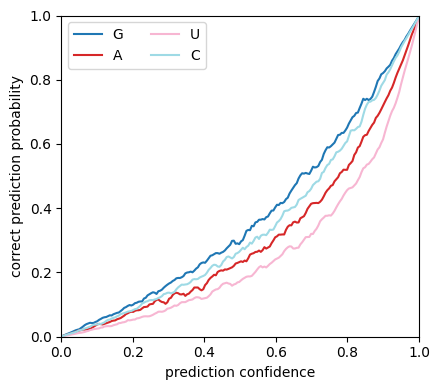

In [6]:
# create confidence mapping
conf = rt.ConfidenceMap("results/{}_cdf.csv".format(os.path.basename(save_path)))

# remap confidence with filter
C = conf.C
x = np.linspace(0.0, 1.0, C.shape[1])

# plot cdfs
cmap = plt.cm.tab20(np.linspace(0.0, 1.0, C.shape[0]))
plt.figure(figsize=(4.5,4))
for i in range(C.shape[0]):
    plt.plot(x, C[i], '-', label=model.module.std_rna[i], color=cmap[i])
#plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.02))
plt.legend(loc='upper left', ncol=2, prop={'size': 10})
plt.ylim(0.0, 1.0)
plt.xlim(0.0, 1.0)
plt.xlabel('prediction confidence')
plt.ylabel('correct prediction probability')
plt.tight_layout()
plt.savefig("results/confidence_mapping_{}.svg".format(os.path.basename(save_path)))
plt.savefig("results/confidence_mapping_{}.png".format(os.path.basename(save_path)))
plt.show()